# **Introduction to GPT Features**

**Instructions**
- Write code in the space indicated with `### START CODE HERE ###`
- Do not use loops (for/while) unless instructions explicitly tell you so. Parallelization in Deep Learning is key!
- If you get stuck, ask for help in Slack or DM `@DRU Team`

**You will learn**
- Main features GPT.
- How to build generative QA based on the given data and pre-trained GPT
- Prepare own dataset and fine-tune GPT model on them.

## Add OpenAI key to Config

Before you, sign up or log in to your OpenAI account and generate an [API key](https://platform.openai.com/account/api-keys).

>**Note that while the first queries are free, there is a specific limit after which payment is required. OpenAI grants an initial budget of $18, more than enough to complete the lab, experiment with the pipeline amd fine-tune model.**

>**Please keep your API key for use during the lab review. We don't store your key, so after verifying your work and earning points, you can delete it in the API keys.**

In [ ]:
# VALIDATION_FIELD[cls] Config

class Config:

  # # Section 1
  gpt3_model_cost = 0.5/1000000
  gpt4_model_cost = 5/1000000

  # Section 2
  wiki_article_path = 'wiki_pages'

  # names of Wikipedia's articles
  article_titles = ['Kyiv', 'History of Kyiv', 'Kyiv Metro', 'Kyiv culture', 'Kyiv Music Fest', 'FC Dynamo Kyiv', 'Igor Sikorsky Kyiv Polytechnic Institute', 'Paton Bridge', 'Saint Sophia Cathedral', 'Transport in Kyiv', 'Kyiv Zoo', 'Kyiv metropolitan area', 'Taras Shevchenko National University of Kyiv', 'Euromaidan', 'Motherland Monument', 'Podil', 'Kyiv TV Tower']

  ### START CODE HERE ###
  # your OpenAI API token key
  openai_api_key = 'gk-proj-rshoLcPfAz3kDazMosiZpBMV88tOdiPeIu-ditsasecretbrodonteventry5X-GGN-SUdz8K8S3p2xdlmaodzqY5H-CMqioUJz-pbmgsuckmydick6PoL'
  ### END CODE HERE ###



## **Section 1 - Try GPT**

[Generative Pre-trained Transformer (GPT)](https://arxiv.org/abs/2005.14165) models by OpenAI have taken the natural language processing (NLP) community by introducing compelling language models. These models can perform various NLP tasks like question answering, textual entailment, text summarisation, Etc. Without any supervised training. These language models need very few to no examples to understand the tasks and perform equivalent to or even better than the state-of-the-art models trained in a supervised fashion.

With the recent releases of [GPT-4o](https://platform.openai.com/docs/models/gpt-4o) and other models, more powerful new versions of OpenAI’s GPT model may take much time before you can exploit their full potential.

We propose considering the possibilities of the OpenAI models they offer and how they can be applied.

First, install the necessary libraries

In [ ]:
!pip install openai
!pip install wget

In [30]:
import json
import os
import openai
from openai import OpenAI

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv

from collections import defaultdict
from typing import List, Dict

### **OpenAI API start**

Now, using OpenAI API, give a prompt to a ChatGPT. Create a [chat completions](https://platform.openai.com/docs/api-reference/chat/create) example from the [official guide](https://platform.openai.com/docs/guides/chat/introduction).

In [31]:
# VALIDATION_FIELD[func] Client_chat_completion

### START CODE HERE ###
client = OpenAI(api_key=Config.openai_api_key)

def client_chat_completion():
  response = client.chat.completions.create(
    model="gpt-3.5-turbo-0125",
    messages=[
      {"role": "user", "content": "This is a test."}
    ]
  )
  return response
### END CODE HERE

test_response = client_chat_completion()
test_response

ChatCompletion(id='chatcmpl-DTAiI0lggfHOxp6I22ugIYjfRemde', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Great, how can I assist you with this test?', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775845066, model='gpt-3.5-turbo-0125', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=11, prompt_tokens=12, total_tokens=23, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

**Expected output:**

```
ChatCompletion(id='chatcmpl-9YqBk4jRNJAKlEBtqgnnjNfrrCEScca',
choices=[Choice(finish_reason='stop', index=0, logprobs=None,
message=ChatCompletionMessage(content='This is a test.',
role='assistant',
function_call=None,
tool_calls=None))],
created=1718090792,
model='gpt-3.5-turbo-0125',
object='chat.completion',
system_fingerprint=None,
usage=CompletionUsage(completion_tokens=5, prompt_tokens=12, total_tokens=17))
```
> Note: The model`s answer can be different but have the same meaning


We got the result with all the query parameters and data. The assistant’s reply in `choices[0].message.content`.

### Response Parameters:

`finish_reason` - indicates the end status of the model's output. Possible values are:

* `stop`: API returned complete model output.
* `length`: Incomplete model output due to max_tokens parameter or token limit.
* `content_filter`: Content omitted due to a flag from the content filters.
* `null`: API response still in progress or incomplete.
usage shows how many tokens the API used. This parameter is important to calculate the cost of your request. We will discuss pricing later.

Explanation of the response structure:

### ChatCompletion:

* `id`: Unique identifier for the chat session.
* `choices`: List of possible responses from the model. In this case, it contains one Choice object.
* `created`: Timestamp of when the session was created.
* `model`: Name of the model used (e.g., gpt-3.5-turbo-0125).
* `object`: Type of object (in this case, chat.completion).
* `system_fingerprint`: System fingerprint if applicable (in this case, None).
* `usage`: Information on token usage, containing:
* `completion_tokens`: Number of tokens in the model's response.
* `prompt_tokens`: Number of tokens in the initial request.
* `total_tokens`: Total number of tokens used.

### Choice:

* `finish_reason`: Reason for the model's completion.
* `index`: Index of the choice (in this case, 0).
* `message`: The message object containing:
* `content`: The content of the assistant's reply.
* `role`: The role of the message (assistant in this case).
* `function_call`: Information on any function call made by the assistant (in this case, None).
* `tool_calls`: Information on any tools called by the assistant (in this case, None).

### **Models usage examples**

We will use the `gpt-3.5-turbo`, one of the current ChatGPT model. This model is accessible on the [web interface](https://chat.openai.com). Your start budget will be enough to end this lab and more.

Using [Completions](https://platform.openai.com/docs/api-reference/completions), you can try the most available powerful model - `gpt-3.5-turbo`. Let`s ask something about Kyiv.

Create a Completion request function with the parameters:
- `max_tokens = 100`
- `temperature = 0`
- `model = "gpt-3.5-turbo"`
- `prompt is a function argument`

In [12]:
# VALIDATION_FIELD[func] Gpt_completion

### START CODE HERE ###
def gpt_completion(prompt, temperature=0, max_tokens=100, model="gpt-3.5-turbo"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=temperature,
        max_tokens=max_tokens
    )
    return response
### END CODE HERE ###

Add prompt `"What is the height of the Kyiv TV tower in metres?"`

In [13]:
# VALIDATION_FIELD[str] Kyiv_prompt

### START CODE HERE ###
kyiv_prompt = "What is the height of the Kyiv TV tower in metres?"
### END CODE HERE ###

kyiv_prompt_response = gpt_completion(kyiv_prompt)

kyiv_prompt_answer = kyiv_prompt_response.choices[0].message.content
kyiv_prompt_answer

'The height of the Kyiv TV tower is 385 meters.'

**Expected output:**

```
The height of the Kyiv TV tower is 385 meters.
```

> Note: The model`s answer can be different but have the same meaning

The correct answer has likely been obtained. Finally, you can check on the page in [Wikipedia](https://en.wikipedia.org/wiki/Kyiv_TV_Tower).

You have tried to ask a simple question that does not require analytical work. It is like a simple Google query. Let us try some math and logical questions.

* Create prompt to calculate `8 * 6 + 6`.

In [14]:
# VALIDATION_FIELD[str] Math_prompt

### START CODE HERE ###
math_prompt = "Give me only the number: 8 * 6 + 6"
### END CODE HERE ###

math_prompt_response = gpt_completion(math_prompt)
math_prompt_answer = math_prompt_response.choices[0].message.content

math_prompt_answer

'54'

**Expected output:**

```
54
```

> Note: The model`s answer can be different but have the same meaning

GPT was able to consider and solve a simple arithmetic example. Let us use the GPT to solve the logic puzzle.

* Create prompt to solve this exercise: `Maks have five apples. Mask give two apples to Maria, after what mother give one apple more to Maks. How many apples have Maks now??`

In [16]:
# VALIDATION_FIELD[str] Logic_prompt

### START CODE HERE ###
logic_prompt = "Maks have five apples. Mask give two apples to Maria, after what mother give one apple more to Maks. How many apples have Maks now? Answer shortly."
### END CODE HERE ###

logic_prompt_response = gpt_completion(logic_prompt)
logic_prompt_answer = logic_prompt_response.choices[0].message.content

logic_prompt_answer

'Maks now has four apples.'

**Expected output:**

```
Maks has 4 apples now.
````

> Note: The model`s answer can be different but have the same meaning

### **Models mistakes**

GPT 3.5-turbo performed your tasks well. You could notice that the results were not immediately correct, and some prompt changes are necessary before getting the correct answer.

GPT is imperfect, so let us look at this issue in more detail.

For example, recent events. gpt-3.5-turbo is `up to June 2021` trained model, so it cannot know who is a Monarch of the United Kingdom now.

* Create prompt `Who is a monarch of the United Kingdom?`

In [17]:
# VALIDATION_FIELD[str] Monarch_UK_prompt

### START CODE HERE ###
monarch_UK_prompt = "Who is a monarch of the United Kingdom?"
### END CODE HERE ###

monarch_UK_prompt_response = gpt_completion(monarch_UK_prompt)
monarch_UK_prompt_answer = monarch_UK_prompt_response.choices[0].message.content

monarch_UK_prompt_answer

'As of September 2021, the monarch of the United Kingdom is Queen Elizabeth II.'

**Expected output:**

```
As of September 2021, the monarch of the United Kingdom is Queen Elizabeth II.
```

> Note: The model`s answer can be different but have the same meaning

We got the wrong answer, and you can check it on [Wikipedia page](https://en.wikipedia.org/wiki/Monarchy_of_the_United_Kingdom) (Charles III has been the monarch since 8 September 2022).

Let's test the mathematical abilities of the model and try a more complex exercise.

* Use your previous math prompt to solve `sqrt(1213*4345)`

In [18]:
# VALIDATION_FIELD[str] Harder_math_prompt

### START CODE HERE ###
harder_math_prompt = "Give me only the number: sqrt(1213 * 4345)"
### END CODE HERE ###

harder_math_prompt_response = gpt_completion(harder_math_prompt)
harder_math_prompt_answer = harder_math_prompt_response.choices[0].message.content

harder_math_prompt_answer

'sqrt(1213 * 4345) ≈ 71.535'

**Expected output:**

```
Anything except 2295.75
```

GPT models are a powerful tool. As you have seen, he can also make mistakes and answer incorrectly to complex and simple questions (try to solve the simple exercise `8*6 + 6*8`).


### **Generate haiku**


However, models can understand what you ask, act according to the limits of the user's words, and even come up with something of your own.

Let us generate a [Haiku](https://www.britannica.com/art/haiku) about ChatGPT using the `Gpt-3.5-turbo` model as the fastest text model.

Create a Completion request with next parameters:
- `max_tokens = 120`
- `temperature = 0.3`
- `model = "gpt-3.5-turbo"`
- `"Tell me a Haiku about ChatGPT"`

In [19]:
# VALIDATION_FIELD[str] Gpt3_haiku

### START CODE HERE ###
gpt3_haiku_prompt = "Tell me a Haiku about ChatGPT"
haiku_gpt3_response = gpt_completion(
    model="gpt-3.5-turbo",
    prompt=gpt3_haiku_prompt,
    temperature=0.3,
    max_tokens=120
)
### END CODE HERE ###

haiku_gpt3_answer = haiku_gpt3_response.choices[0].message.content
print(haiku_gpt3_answer)

ChatGPT so wise
Answers flowing like a stream
Conversations thrive


Let's compare with `gpt-4-turbo` model as the bigger model.

Create a Completion request with next parameters:
- `max_tokens = 120`
- `temperature = 0.3`
- `model = "gpt-4-turbo"`
- `"Tell me a Haiku about ChatGPT"`

In [20]:
# VALIDATION_FIELD[str] Gpt4_haiku

### START CODE HERE ###
gpt4_haiku_prompt = "Tell me a Haiku about ChatGPT"
haiku_gpt4_response = gpt_completion(
    model="gpt-4-turbo",
    prompt=gpt4_haiku_prompt,
    temperature=0.3,
    max_tokens=120
)
### END CODE HERE ###

haiku_gpt4_answer = haiku_gpt4_response.choices[0].message.content
print(haiku_gpt4_answer)

Whispers of circuits,
ChatGPT spins tales and wisdom,
Silent mind awakes.


Now compare both answers

In [21]:
print('GPT 3.5 turbo model haiku:')
print(haiku_gpt3_response.choices[0].message.content)
print('------------------------------------')
print('GPT 4 turbo model haiku:')
print(haiku_gpt4_response.choices[0].message.content)
print('------------------------------------')
print('GPT 3.5 cost: %.8f $' % (Config.gpt3_model_cost * haiku_gpt3_response.usage.total_tokens))
print('GPT 4 cost: %.8f $' % (Config.gpt4_model_cost * haiku_gpt4_response.usage.total_tokens))

GPT 3.5 turbo model haiku:
ChatGPT so wise
Answers flowing like a stream
Conversations thrive
------------------------------------
GPT 4 turbo model haiku:
Whispers of circuits,
ChatGPT spins tales and wisdom,
Silent mind awakes.
------------------------------------
GPT 3.5 cost: 0.00001550 $
GPT 4 cost: 0.00017500 $


As you can see, the GPT-4 model creates more creative and better haiku than GPT-3.5. However, using GPT-4o is more expensive than GPT-3.5, following this table:

<table>
  <tr>
    <td>gpt-3.5-turbo:</td>
    <td> $0.00001550</td>
  </tr>
  <tr>
    <td>gpt-4o:</td>
    <td> $0.00017400</td>
  </tr>
</table>

We need to pay more for better results. You can learn more about OpenAI pricing on the [official website](https://openai.com/pricing).

### **Creative solution**

GPT is a powerful multitasking model that can solve many different tasks. You can ask any question, how who is the Great Britan monarch or information about a favorite character, and solve math and logic tasks. However, the capabilities of the models are wider than this.

Using GPT, you can solve more complex tasks, and let's try to do something.

### **GraphGPT**

The main idea is to create a prompt that will allow us to convert unstructured natural language into a knowledge graph.

To do this, you need to create a prompt from the task and provide the GPT recording formats and an example of execution.


You need fill `//-- add your text here --//` in the following prompt:
> * Describe the task of finding as many connections as possible and writing them down in a list.
* Note that the single format `[ENTITY 1, RELATIONSHIP, ENTITY 2]` should be used, relations are directed, and the order is important.
* For testing, use `Maks, Petro and Vlad are colleagues.`

In [29]:
# VALIDATION_FIELD[str] Graph_prompt

### START CODE HERE ###
graph_prompt = """
Return a list of all passible connections, where each connection is in format `[ENTITY_i, RELATIONSHIP, ENTITY_j]`. Relations are directed, and the order is important. 
Statement: 1. ENTITIES: Maks, Petro, Vlad;
           2. RELATIONSHIP: colleague.
Answer format: Return ONLY a valid JSON array and nothing more [[connection_1], ..., [connection_N]]
"""
### END CODE HERE ###

graph_prompt_response = gpt_completion(graph_prompt)
graph_prompt_answer = graph_prompt_response.choices[0].message.content

print(graph_prompt_answer)

[
    ["Maks", "colleague", "Petro"],
    ["Petro", "colleague", "Maks"],
    ["Maks", "colleague", "Vlad"],
    ["Petro", "colleague", "Vlad"],
    ["Vlad", "colleague", "Maks"],
    ["Vlad", "colleague", "Petro"]
]


Expected output:
```
    [["Maks", "colleague", "Petro"],
     ["Maks", "colleague", "Vlad"],
     ["Petro", "colleague", "Maks"],
     ["Petro", "colleague", "Vlad"],
     ["Vlad", "colleague", "Maks"],
     ["Vlad", "colleague", "Petro"]]
```



Create functions using [networkx](https://networkx.org/documentation/stable/reference/introduction.html) for visualizing the obtained connections:

In [30]:
# VALIDATION_FIELD[str] create_show_graph

def create_relationships_dataframe(answer_data):
    # Answer data is a string, we need to extract the JSON part
    json_start = answer_data.find('[')
    json_end = answer_data.rfind(']') + 1
    json_data = answer_data[json_start:json_end]

    # Close JSON array if it's incomplete
    if answer_data.count('[') > answer_data.count(']'):
        json_data += ']]'

    # Parse the JSON data
    relationships = json.loads(json_data)
    from_label = [relationship[0] for relationship in relationships]
    weight_label = [relationship[1] for relationship in relationships]
    to_label = [relationship[2] for relationship in relationships]

    # Create a DataFrame
    df_relationships = pd.DataFrame({'from': from_label, 'to': to_label, 'weight': weight_label})
    return df_relationships

def get_connection_relationship_weight(edge, df_relation):
    name = df_relation.loc[(df_relation['from'] == edge[0]) & (df_relation['to'] == edge[1])]['weight'].iloc[0]
    return name

def show_graph(answer_data):
    if isinstance(answer_data, list):
        relationships = answer_data
    else:
        print("Unsupported data format")
        return

    from_label = [relationship[0] for relationship in relationships]
    weight_label = [relationship[1] for relationship in relationships]
    to_label = [relationship[2] for relationship in relationships]
    df_relationships = pd.DataFrame({'from': from_label, 'to': to_label, 'weight': weight_label})

    G = nx.from_pandas_edgelist(df_relationships, 'from', 'to', create_using=nx.DiGraph())

    pos = nx.spring_layout(G)

    nx.draw(G, pos, with_labels=True, node_size=800, node_color="lightblue")

    labels = {e: df_relationships.loc[(df_relationships['from'] == e[0]) & (df_relationships['to'] == e[1])]['weight'].iloc[0] for e in G.edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    # show graph
    plt.show()

Now you can visualize your graph.

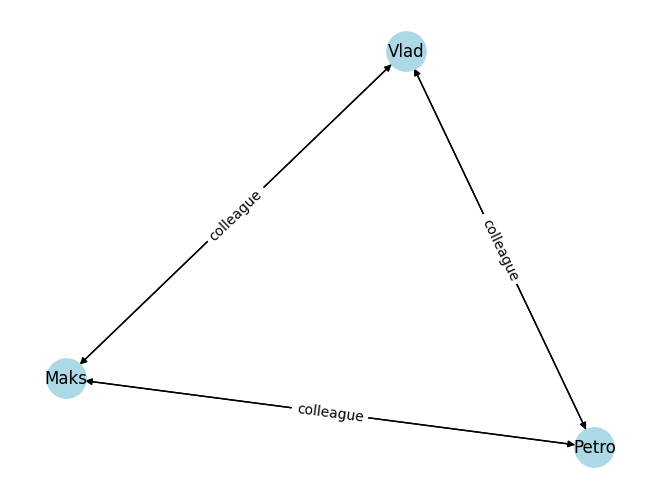

In [31]:
data = json.loads(graph_prompt_answer)
show_graph(data)

The graph you obtained show the relationship between Peter, Vlad and Max, as specified in your prompt. All of them are colleagues and related to each other.

To make sure that the prompt you created works correctly, let us consider a more complex condition by adding external relations


You need fill `//-- add your text here --//` in the following prompt:
> * Paste your description and formatting.
* Generate next relationships graph: `Markus, Mario, Clara and Mykyta are friends. Maria is Clara teacher and Markus mother and Sam lives with Mario.`

In [34]:
# VALIDATION_FIELD[str] Harder_graph_prompt

### START CODE HERE ###
harder_graph_prompt = """
Return a list of all passible connections, where each connection is in format `[ENTITY_i, RELATIONSHIP, ENTITY_j]`. Relations are directed, and the order is important.
Statement: 1. ENTITIES: Markus, Mario, Clara, Mykyta, Sam.
           2. RELATIONSHIP: friend: Markus, Mario, Clara, Mykyta are friends of eacj other; teacher: Maria is Clara teacher (directed); mother: Maria is Markus mother (directed); lives with: Sam lives with Mario.
Answer format: Return ONLY a valid JSON array and nothing more [[connection_1], ..., [connection_N]]
"""
### END CODE HERE ###

harder_graph_prompt_response = gpt_completion(harder_graph_prompt, max_tokens=600)
harder_graph_prompt_answer = harder_graph_prompt_response.choices[0].message.content

print(harder_graph_prompt_answer)

[
    ["Markus", "friend", "Mario"],
    ["Markus", "friend", "Clara"],
    ["Markus", "friend", "Mykyta"],
    ["Mario", "friend", "Markus"],
    ["Mario", "friend", "Clara"],
    ["Mario", "friend", "Mykyta"],
    ["Clara", "friend", "Markus"],
    ["Clara", "friend", "Mario"],
    ["Clara", "friend", "Mykyta"],
    ["Mykyta", "friend", "Markus"],
    ["Mykyta", "friend", "Mario"],
    ["Mykyta", "friend", "Clara"],
    ["Maria", "teacher", "Clara"],
    ["Maria", "mother", "Markus"],
    ["Sam", "lives with", "Mario"]
]


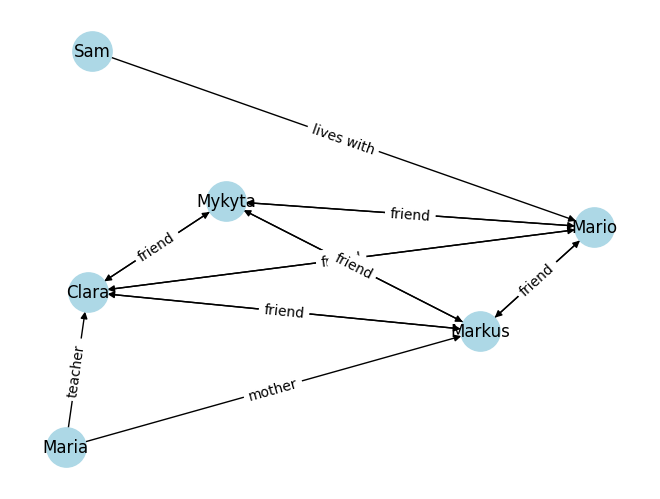

In [35]:
result = json.loads(harder_graph_prompt_answer)
show_graph(result)

Expected output:
```
[['Markus', 'friend', 'Mario'],
 ['Markus', 'friend', 'Clara'],
 ['Markus', 'mother', 'Maria'],
 ['Mario', 'friend', 'Markus'],
 ['Mario', 'friend', 'Clara'],
 ['Mario', 'friend', 'Mykyta'],
 ['Clara', 'friend', 'Markus'],
 ['Clara', 'friend', 'Mario'],
 ['Clara', 'teacher', 'Maria'],
 ['Mykyta', 'friend', 'Mario'],
 ['Maria', 'teacher', 'Clara'],
 ['Maria', 'mother', 'Markus'],
 ['Sam', 'lives with', 'Mario']]
 ```

> Note: The model`s answer can be different but have the same meaning


## **Section 2 - Search Engine with GPT-3**



In [ ]:
# Install necessary libraries
!pip install langchain langchain-openai langchain-community faiss-cpu tiktoken

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.vectorstores import FAISS
from langchain.chains.retrieval_qa.base import RetrievalQA

### **Build a GPT-Powered Search Engine**

Recently, there has been a lot of buzz around OpenAI’s latest language model, ChatGPT. Known for its versatility—from debugging code to rewriting text in various styles—ChatGPT is a variant of the GPT-3.5 family, built on billions of parameters and trained on vast datasets like the Common Crawl corpus. This extensive training helps the model generate impressively informed responses.

While it’s exciting to see a model capable of engaging in natural conversations and simulating intelligence, it's important to remain cautious. Large language models can sometimes “hallucinate” details—that is, generate plausible-sounding text that might not be factually correct. In contrast, traditional semantic search engines, like those developed by deepset, usually rely on extractive question-answering techniques that pull direct snippets from a knowledge base rather than generating entirely new text.

### **The Rise of Large Language Models**

The scale of modern language models is truly staggering. For instance, while the largest BERT model contains around 336 million parameters, OpenAI’s most advanced GPT-3.5 model has roughly 520 times that number. This massive increase in capacity allows GPT-based models to excel at grasping implications and intent. They can maintain context throughout a conversation—recognizing references like “he” or “earlier”—and even point out when a question doesn’t quite make sense. Generating coherent language from scratch, however, remains a far more challenging task than simply retrieving text segments.


### **The RetrievalQA Pipeline with LangChain and Faiss**

In this section, you will implement a generative search engine using **LangChain’s** RetrievalQA pipeline. This modern approach integrates two core components:

1.	**Retriever**: Built on a Faiss vector store, the retriever searches for and retrieves the document chunks that are most semantically relevant to the user’s query.
2.	**Language Model Generator**: Powered by GPT-4, the language model uses the retrieved chunks as context to generate a coherent, natural language answer.

#### **Downloading Wikipedia Articles**

Download a collection of Wikipedia articles in a ZIP archive. The downloaded file is then unzipped to extract the articles. These files serve as raw data for further processing.

In [8]:
# VALIDATION_FIELD[str] Download_articles

import wget
import zipfile

wget.download('https://dru.fra1.digitaloceanspaces.com/DL_pytorch/datasets/07_attention_transformers/GPT-3/wikipedia_articles.zip')
with zipfile.ZipFile("wikipedia_articles.zip","r") as zip_ref:
    zip_ref.extractall("")

#### **Document Processing**

In this step, you need to load and preprocess the downloaded Wikipedia articles. Perform the following steps:

- **Loading Documents:**
  Use LangChain’s `TextLoader` to read text files stored in the `wiki_pages` folder. Each file corresponds to a Wikipedia article, and each has a name equal to its title.

- **Splitting Documents:**
  Using the `RecursiveCharacterTextSplitter`, split each document into smaller chunks. The splitter should create chunks of with size of `200` characters with a chunk_overlap of `50` characters to help maintain context across splits.

This preprocessing ensures that the documents are in a manageable format for embedding and semantic search.




In [33]:
# VALIDATION_FIELD[str] Preprocessing_documents

article_titles = Config.article_titles

### START CODE HERE ###

# Initialize the text splitter. Use a recursive character splitter to split text into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50,
    length_function=len,
    is_separator_regex=False,
)

processed_docs = []
for title in article_titles:
    loader = TextLoader(f"./{Config.wiki_article_path}/{title}.txt", encoding="utf8")
    docs = loader.load()
    split_docs = text_splitter.split_documents(docs)
    processed_docs.extend(split_docs)

### END CODE HERE ###
print("\nDocuments have been successfully preprocessed and stored.")


Documents have been successfully preprocessed and stored.


#### **Building the Vector Store with Faiss**

After processing the documents, convert them into vector embeddings:

- **Embeddings:**
  Use OpenAI’s `text-embedding-ada-002` model via LangChain’s `OpenAIEmbeddings` to generate embeddings for each document chunk. Don't forget to insert your API key!

- **Vector Store:**
  Store the generated embeddings in a Faiss vector database. Faiss allows for efficient semantic search by enabling similarity comparisons between query embeddings and document embeddings.

This vector store will be the backbone of your retrieval system.


In [34]:
# VALIDATION_FIELD[str]: Vector_store

### START CODE HERE ###

# Initialize the OpenAI embeddings using the "text-embedding-ada-002" model.
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002", api_key=Config.openai_api_key)

# Create a Faiss vector store from the processed documents using the OpenAI embeddings.
vector_store = FAISS.from_documents(processed_docs, embeddings)

### END CODE HERE ###

#### **Setting Up the Retriever and LLM for RetrievalQA**

Configure the retrieval and generation components to form your end-to-end QA pipeline:

- **Retriever:**
  Convert the Faiss vector store into a retriever that fetches the top `5` relevant document chunks based on the semantic similarity to a given query.

- **Language Model (LLM):**
  Initialize a `ChatOpenAI` instance with the `gpt-4` model. This model will generate natural language responses based on the retrieved document chunks.
  Set the `temperature` parameter to 0.3 for greater determinism.<br>Don't forget to pass your API key!

- **RetrievalQA Chain:**
  Build a `qa_chain` via `RetrievalQA`'s `from_chain_type` method. The `RetrievalQA` chain will integrate the retriever and the LLM. It will first retrieve the relevant text chunks and then `“stuff”` them into a prompt for GPT-4 to generate a comprehensive answer.

In [ ]:
# VALIDATION_FIELD[str] Initialize_retriever

### START CODE HERE ###

# Create a retriever from the vector store, returning the top 5 relevant documents.
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

# Initialize the GPT-4 based ChatOpenAI model.
llm = ChatOpenAI(
    model="gpt-4",
    temperature=0.3,
    api_key=Config.openai_api_key
)

# Build the RetrievalQA chain that first retrieves relevant document chunks and then
# “stuffs” (combines) them into a prompt for GPT-4 to generate a natural language answer.
qa_chain = RetrievalQA.from_chain_type(llm, retriever=retriever, chain_type="stuff")
### END CODE HERE ###

# A quick test query:
response = qa_chain.invoke("Where is located Kyiv zoo?")
print("Response for 'Where is located Kyiv zoo?':")
print(response["result"])

Response for 'Where is located Kyiv zoo?':
The Kyiv Zoo is located in Kyiv, Ukraine.


#### **Query Pipeline Function**

Implement the `query_pipeline` function to handle user queries and output answers:

- **Input:**
  The function should accept a query string along with optional parameters for controlling the number of retrieved documents (`top_k_retriever`) and the maximum tokens for the generated answer (`max_tokens`).

- **Processing:**
  The query should pass to the `RetrievalQA` chain, which retrieves relevant document chunks and then generates an answer using GPT-4.

- **Output:**
  The function should print and return the generated answer, providing a straightforward way to interact with the pipeline.

This function will serve as the primary interface for querying the system.

In [14]:
# VALIDATION_FIELD[str] Query_pipeline

def query_pipeline(query, top_k_retriever=5, max_tokens=50):
    """
    Query the RetrievalQA pipeline and print the answer.

    Note:
      - The `top_k_retriever` and `max_tokens` parameters are not directly used in this simple
        implementation since the chain is already configured. You could modify the underlying
        retriever or LLM settings if dynamic control is needed.
    """
    ### START CODE HERE ###
    result = qa_chain.invoke(query)
    ### END CODE HERE ###

    if not result or "result" not in result:
        print("No answers found.")
        return None

    answer = result["result"]
    print(f"Query: {query}\nAnswer: {answer}\n")
    return answer

Let's test your pipeline:

In [15]:
# VALIDATION_FIELD[str] Query_pipeline_1

query_pipeline_first = query_pipeline("What is Kyiv known for?")
print(query_pipeline_first)

Query: What is Kyiv known for?
Answer: Kyiv is known for its architecture, historically significant sites and monuments such as Khreshchatyk, European Square and the Kyiv Pechersk Lavra. It is also home to Ukraine's ministry of education and science, and is noted for its contributions to medical and computer science research.

Kyiv is known for its architecture, historically significant sites and monuments such as Khreshchatyk, European Square and the Kyiv Pechersk Lavra. It is also home to Ukraine's ministry of education and science, and is noted for its contributions to medical and computer science research.


Expected result:
```
"Kyiv is known for its architecture, historically significant sites and monuments ..."
```
> Note: The answer can be different but have the same meaning.



In [16]:
# VALIDATION_FIELD[str] Query_pipeline_2

query_pipeline_second = query_pipeline("Do people from Kyiv have their own culture?")
print(query_pipeline_second)

Query: Do people from Kyiv have their own culture?
Answer: Yes, people from Kyiv have their own culture. The city has a rich history dating back to the 3rd to 5th centuries with the Kyiv culture. Over the centuries, the city's inhabitants have made efforts to preserve their native culture. Today, Kyiv continues to be a significant cultural center in Ukraine.

Yes, people from Kyiv have their own culture. The city has a rich history dating back to the 3rd to 5th centuries with the Kyiv culture. Over the centuries, the city's inhabitants have made efforts to preserve their native culture. Today, Kyiv continues to be a significant cultural center in Ukraine.


Expected result:

```
"Yes, people from Kyiv have their own culture, known as the Kyiv or Kiev culture ..."
```
> Note: The answer can be different but have the same meaning.

In [17]:
# VALIDATION_FIELD[str] Query_pipeline_3

query_pipeline_third = query_pipeline("Tell me about some interesting places in Kyiv")
print(query_pipeline_third)

Query: Tell me about some interesting places in Kyiv
Answer: Kyiv, the capital of Ukraine, is home to many historically significant sites and monuments. Among the most famous are the St. Sophia Cathedral and the Kyiv Pechersk Lavra, both of which are renowned historical architecture complexes. Khreshchatyk, the main street of Kyiv, and European Square are also popular sites. Unfortunately, some landmarks like the House of the Kyiv magistrate, Kyiv Brotherhood Monastery Epiphany Cathedral, Church of Nicholas the Good, and Church of the Resurrection have been lost over time. Despite this, Kyiv is recognized for its green spaces and was even inscribed into the TOP30 European Green City Index.

Kyiv, the capital of Ukraine, is home to many historically significant sites and monuments. Among the most famous are the St. Sophia Cathedral and the Kyiv Pechersk Lavra, both of which are renowned historical architecture complexes. Khreshchatyk, the main street of Kyiv, and European Square are als

Expected result:

```
"In Kyiv, there are several interesting and historically significant sites. Khreshchatyk is the main street ..."
```
> Note: The answer can be different but have the same meaning.

## **Section 3 - Fine-tune GPT**

Fine-tuning is the process of training a [Large Language Model (LLM)](https://en.wikipedia.org/wiki/Large_language_model) to recognize a specific pattern of input and output that can be applied to any custom NLP task.

Taken from the [official docs](https://platform.openai.com/docs/guides/fine-tuning), fine-tuning lets you get more out of the GPT-3 models by providing the following:
* Higher quality results than prompt design
* Ability to train on more examples than can fit in a * prompt
* Token savings due to shorter prompts
* Lower latency requests

Fine-tuning involves the following steps:
* Prepare and upload training data
* Train a new fine-tuned model
* Use your fine-tuned model

In [18]:
# VALIDATION_FIELD[str] Download_dataset

import wget
wget.download('https://dru.fra1.digitaloceanspaces.com/DL_pytorch/datasets/07_attention_transformers/GPT-3/QA_DataRoot_Labs.csv')

'QA_DataRoot_Labs.csv'

In [19]:
data = pd.read_csv('QA_DataRoot_Labs.csv')

print('Prompt:', data.iloc[0]['prompt'])
print('Completion:', data.iloc[0]['completion'])

Prompt: What is it DataRoot Labs?
Completion:  DataRoot Labs is a full-service Data Science & Artificial Intelligence R&D company with main focus on Big Data Management & Strategy Consulting, Data Science & Engineering.DataRoot Labs consists of AI, HighLoad and Science teams — geeks, really good at building & assembling AI-Enabled solutions & Infrastructures, complex scientific R&D.AI Lab delivers to our partners and clients the unique value leveraging Deep Learning, Computer Vision, NLP, Advanced Scoring Models


Our dataset have such view:
```
{"prompt": "<question>", "completion": "<ideal answer>"}
{"prompt": "<question>", "completion": "<ideal answer>"}
{"prompt": "<question>", "completion": "<ideal answer>"}
```

But the dataset should be of the following format:

```
{"messages":[{"role": "system", "content": "You are a helpful assistant."}, {"role": "user", "content": "Hello!"}, {"role": "assistant", "content": "Hello! How can I assist you today?"}]}
{"messages":[{"role": "system", "content": "You are a helpful assistant."}, {"role": "user", "content": "What's the weather today?"}, {"role": "assistant", "content": "The weather is sunny and warm today."}]}
```
and saved in `.jsonl` format file.

### Create a **JSONL** file to fine tune it.

> Task:
- create a jsonl file with the correct format

In [22]:
# VALIDATION_FIELD[str] Create_fine_tune_jsonl

csv_file_path = 'QA_DataRoot_Labs.csv'
jsonl_file_path = 'QA_DataRoot_Labs_chat.jsonl'

with open(csv_file_path, mode='r', encoding='utf-8') as csv_file, open(jsonl_file_path, mode='w', encoding='utf-8') as jsonl_file:
    csv_reader = csv.DictReader(csv_file)

    for row in csv_reader:
        ### START CODE HERE ###
        json_record = {
            "messages": [
                {"role": "user", "content": row.get("prompt", "")},
                {"role": "assistant", "content": row.get("completion", "")}
            ]
        }
        ### END CODE HERE ###
        jsonl_file.write(json.dumps(json_record, ensure_ascii=False) + '\n')

Check data formatting

In [23]:
# VALIDATION_FIELD[str] Test_jsonl_file

# Load the dataset
with open(jsonl_file_path, 'r', encoding='utf-8') as f:
    dataset = [json.loads(line) for line in f]

# Initial dataset stats
print("Num examples:", len(dataset))
print("First example:")
for message in dataset[0]["messages"]:
    print(message)

Num examples: 36
First example:
{'role': 'user', 'content': 'What is it DataRoot Labs?'}
{'role': 'assistant', 'content': ' DataRoot Labs is a full-service Data Science & Artificial Intelligence R&D company with main focus on Big Data Management & Strategy Consulting, Data Science & Engineering.DataRoot Labs consists of AI, HighLoad and Science teams — geeks, really good at building & assembling AI-Enabled solutions & Infrastructures, complex scientific R&D.AI Lab delivers to our partners and clients the unique value leveraging Deep Learning, Computer Vision, NLP, Advanced Scoring Models'}


Expected output:

```
Num examples: 36
First example:
{'role': 'user', 'content': 'What is it DataRoot Labs?'}
{'role': 'assistant', 'content': ' DataRoot Labs is a full-service Data Science & Artificial Intelligence R&D company with main focus on Big Data Management & Strategy Consulting, Data Science & Engineering.DataRoot Labs consists of AI, HighLoad and Science teams — geeks, really good at building & assembling AI-Enabled solutions & Infrastructures, complex scientific R&D.AI Lab delivers to our partners and clients the unique value leveraging Deep Learning, Computer Vision, NLP, Advanced Scoring Models'}
```

### **Upload a training file**

Once you have the data validated, the file needs to be uploaded using the [Files API](https://platform.openai.com/docs/api-reference/files/create) in order to be used with a fine-tuning jobs:

> **Task:**
1. Use the `client.files.create` method to upload the file.
2. Set the purpose parameter to `fine-tune`.

In [27]:
# VALIDATION_FIELD[str] Upload_training_file

### START CODE HERE ###
upload_file = client.files.create(
    file=open("./QA_DataRoot_Labs_chat.jsonl", "rb"),
    purpose="fine-tune"
)
### END CODE HERE ###

file_id = upload_file.id

### **Create a fine-tuned model**

After ensuring you have the right amount and structure for your dataset, and have uploaded the file, the next step is to create a fine-tuning job. We support creating fine-tuning jobs via the [fine-tuning UI](https://platform.openai.com/finetune) or programmatically.


> **Task:**
1. Use the `client.fine_tuning.jobs.create` method to create a fine-tuning job.
2. Set the `training_file` parameter to the file_id obtained from the file upload.
3. Set the model parameter to `"gpt-3.5-turbo"`.

In [28]:
# VALIDATION_FIELD[str] Create_job

### START CODE HERE ###
create_job = client.fine_tuning.jobs.create(
    model="gpt-3.5-turbo",
    training_file=file_id
)
### END CODE HERE ###

job_id = create_job.id

### **Use a fine-tuned model**

When a job has succeeded, you will see the fine_tuned_model field populated with the name of the model when you retrieve the job details. You may now specify this model as a parameter to in the [Chat Completions](https://platform.openai.com/docs/api-reference/chat).

After your job is completed, the model should be available right away for inference use. In some cases, it may take several minutes for your model to become ready to handle requests. If requests to your model time out or the model name cannot be found, it is likely because your model is still being loaded. If this happens, try again in a few minutes.

>**Task:**
Find your model in [playground ChatGPT](https://platform.openai.com/finetune) and put the name to reference code:

In [29]:
# VALIDATION_FIELD[str] Reference_fine_tune_model
### START CODE HERE ###
fine_tuned_model_name = "ft:gpt-3.5-turbo-0125:dimka::DT9Aekf4"
### END CODE HERE ###

completion = client.chat.completions.create(
  model=fine_tuned_model_name,
  messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Where is DataRoot Labs headquartered?"}
  ]
)

print(completion.choices[0].message.content)

DataRoot Labs is headquartered in Kyiv, Ukraine.


Expected output:
```
DataRoot Labs is headquarted in Kyiv, Ukraine.
```

## Conclusion
As you can see, your model fits well the hypothesis function to the data.

What's next:
- Try experimenting with GPT models and prompt
- Using OpenAI API try text to image DALL·E or speech to text Whisper models.
- Fine-tune own model using another QA dataset.

Make sure that you didn't add or delete any notebook cells. Otherwise your work may not be accepted by the validator!